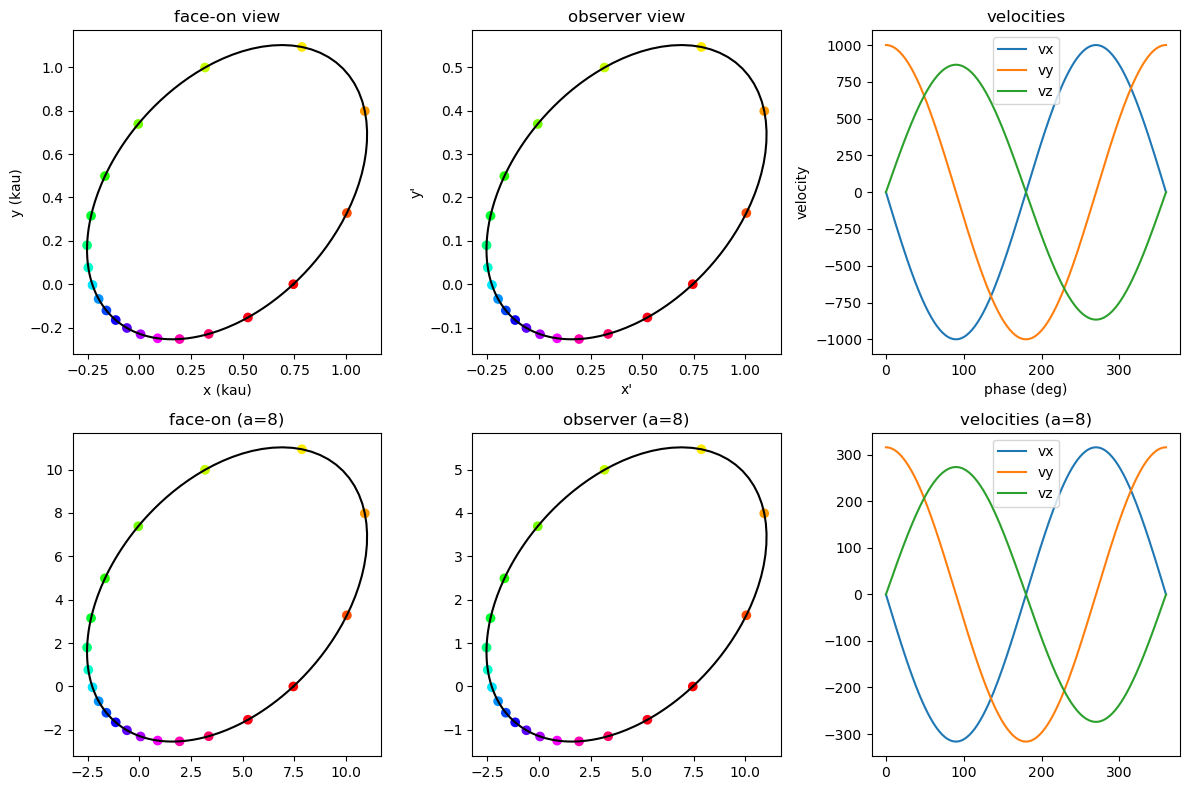

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# =============================
# PARAMETERS (you can tweak)
# =============================
M = 2.0  # solar masses
e = 0.75
a = 0.8  # kau (try 8 later)
phi0 = -135 * np.pi/180
inc = 60 * np.pi/180

# =============================
# ORBIT PARAMETRIZATION
# =============================
phi = np.linspace(0, 2*np.pi, 200)

r = a * (1 - e**2) / (1 + e*np.cos(phi - phi0))

# face-on orbit
x = r * np.cos(phi)
y = r * np.sin(phi)

# projected (observer)
x_proj = x
y_proj = y * np.cos(inc)

# =============================
# VELOCITIES (qualitative)
# =============================
vx = -np.sin(phi)
vy = np.cos(phi)
vz = np.sin(phi) * np.sin(inc)

# scale for visualization
vx *= 1000
vy *= 1000
vz *= 1000

# =============================
# PLOTTING
# =============================
fig, axs = plt.subplots(2, 3, figsize=(12,8))

# -------- Row 1 (a = 0.8 kau) --------
axs[0,0].plot(x, y, 'k-')
axs[0,0].scatter(x[::10], y[::10], c=phi[::10], cmap='hsv')
axs[0,0].set_title("face-on view")
axs[0,0].set_xlabel("x (kau)")
axs[0,0].set_ylabel("y (kau)")

axs[0,1].plot(x_proj, y_proj, 'k-')
axs[0,1].scatter(x_proj[::10], y_proj[::10], c=phi[::10], cmap='hsv')
axs[0,1].set_title("observer view")
axs[0,1].set_xlabel("x'")
axs[0,1].set_ylabel("y'")

axs[0,2].plot(phi*180/np.pi, vx, label='vx')
axs[0,2].plot(phi*180/np.pi, vy, label='vy')
axs[0,2].plot(phi*180/np.pi, vz, label='vz')
axs[0,2].set_title("velocities")
axs[0,2].set_xlabel("phase (deg)")
axs[0,2].set_ylabel("velocity")
axs[0,2].legend()

# -------- Row 2 (a = 8 kau) --------
a2 = 8
r2 = a2 * (1 - e**2) / (1 + e*np.cos(phi - phi0))
x2 = r2 * np.cos(phi)
y2 = r2 * np.sin(phi)
y2_proj = y2 * np.cos(inc)

axs[1,0].plot(x2, y2, 'k-')
axs[1,0].scatter(x2[::10], y2[::10], c=phi[::10], cmap='hsv')
axs[1,0].set_title("face-on (a=8)")

axs[1,1].plot(x2, y2_proj, 'k-')
axs[1,1].scatter(x2[::10], y2_proj[::10], c=phi[::10], cmap='hsv')
axs[1,1].set_title("observer (a=8)")

# velocities scaled down (Kepler)
scale = np.sqrt(a/a2)
axs[1,2].plot(phi*180/np.pi, vx*scale, label='vx')
axs[1,2].plot(phi*180/np.pi, vy*scale, label='vy')
axs[1,2].plot(phi*180/np.pi, vz*scale, label='vz')
axs[1,2].set_title("velocities (a=8)")
axs[1,2].legend()

plt.tight_layout()
plt.show()